# Import Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import plot_importance
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier


from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, RandomizedSearchCV, validation_curve, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    auc,
    RocCurveDisplay,
    log_loss,
    make_scorer
)

# from pprint import pprint

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 120)

# Load Data

In [ ]:
## IMPORT DATA

datafolderpath = ""
application_train = pd.read_csv(f"{datafolderpath}home-credit-default-risk/application_train.csv")
# application_test = pd.read_csv(f"{datafolderpath}home-credit-default-risk/application_test.csv")
# bureau_balance = pd.read_csv(f"{datafolderpath}home-credit-default-risk/bureau_balance.csv")
bureau = pd.read_csv(f"{datafolderpath}home-credit-default-risk/bureau.csv")
credit_card_balance = pd.read_csv(f"{datafolderpath}home-credit-default-risk/credit_card_balance.csv")
# installments_payments = pd.read_csv(f"{datafolderpath}home-credit-default-risk/installments_payments.csv")
POS_CASH_balance = pd.read_csv(f"{datafolderpath}home-credit-default-risk/POS_CASH_balance.csv")
# previous_application = pd.read_csv(f"{datafolderpath}home-credit-default-risk/previous_application.csv")

# column_description = pd.read_csv(f"{datafolderpath}home-credit-default-risk/HomeCredit_columns_description.csv")

In [4]:
print(application_train.info())
print('')
# print(application_test.info())

# study data
initial_categorical_cols = application_train.select_dtypes(include=['object', 'category']).columns.tolist()
initial_numeric_cols = application_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'# of categorical columns: {len(initial_categorical_cols)}')
print(f'# of numeric columns: {len(initial_numeric_cols)}')

application_columns = application_train.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None

# of categorical columns: 16
# of numeric columns: 106


# Merge Data

In [ ]:
## MERGE BUREAU DATA

# print(bureau.shape)
# print(bureau.info())

# only keep numeric columns
bureau_numeric = bureau.drop(['CREDIT_ACTIVE', 'CREDIT_CURRENCY','CREDIT_TYPE'], axis=1)

# collapse rows using group mean
bureau_mean = bureau_numeric.groupby('SK_ID_CURR').mean()
print(bureau_mean.shape)
print(bureau_mean.isna().sum().sort_values(ascending=False))

# drop col with too many missing values
bureau_mean = bureau_mean.drop(['AMT_ANNUITY', 'DAYS_ENDDATE_FACT'], axis=1)

# fill missing values with 0
cols_with_missing_values = ['AMT_CREDIT_MAX_OVERDUE', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_DEBT', 'DAYS_CREDIT_ENDDATE', 'AMT_CREDIT_SUM']
bureau_mean[cols_with_missing_values] = bureau_mean[cols_with_missing_values].fillna(0)
# check
# print(bureau_mean.isna().sum().sort_values(ascending=False))

# Merge with application
cols_to_add = [c for c in bureau_mean.columns if c not in application_columns or c == 'SK_ID_CURR']
# print(cols_to_add)

application_merged = application_train.merge(bureau_mean[cols_to_add], on="SK_ID_CURR", how="left")
# application_merged = application_train.merge(bureau_mean, on="SK_ID_CURR", how="left")

# Flag Missing Bureau Data
application_merged["missing_bureau"] = application_merged["AMT_CREDIT_MAX_OVERDUE"].isna().astype(int)

# Fill na with 0
application_merged[cols_to_add] = application_merged[cols_to_add].fillna(0)



## MERGE CREDIT CARD BALANCE DATA
# print(credit_card_balance.shape)
# print(credit_card_balance.info())

# only keep numeric columns
numeric_cols_ccb = credit_card_balance.select_dtypes(include=['int64', 'float64']).columns.tolist()
credit_card_balance_numeric = credit_card_balance[numeric_cols_ccb]

# collapse rows using group mean
credit_card_balance_mean = credit_card_balance_numeric.groupby('SK_ID_CURR').mean()
# print(credit_card_balance_mean.shape)
# print(credit_card_balance_mean.isna().sum().sort_values(ascending=False))

# fill missing values with 0
cols_with_missing_values = ['AMT_PAYMENT_CURRENT', 'AMT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_ATM_CURRENT']
credit_card_balance_mean = credit_card_balance_mean.drop(cols_with_missing_values, axis=1)
# credit_card_balance_mean[cols_with_missing_values] = credit_card_balance_mean[cols_with_missing_values].fillna(0)
# check
# print(credit_card_balance_mean.isna().sum().sort_values(ascending=False))

# Merge with application
cols_to_add = [c for c in credit_card_balance_mean.columns if c not in application_merged.columns or c == 'SK_ID_CURR']
# print(cols_to_add)

application_merged = application_merged.merge(credit_card_balance_mean[cols_to_add], on="SK_ID_CURR", how="left")

# Flag Missing ccbalance Data
application_merged["missing_ccbalance"] = application_merged["AMT_TOTAL_RECEIVABLE"].isna().astype(int)

# Fill na with 0
application_merged[cols_to_add] = application_merged[cols_to_add].fillna(0)




## MERGE POS CASH DATA
# print(POS_CASH_balance.shape)
# print(POS_CASH_balance.info())

categorical_cols = POS_CASH_balance.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols_poscash = POS_CASH_balance.select_dtypes(include=['int64', 'float64']).columns.tolist()
# print(f'# of categorical columns: {len(initial_categorical_cols)}')
# print(f'# of numeric columns: {len(initial_numeric_cols)}')

# only keep numeric columns
POS_CASH_balance_numeric = POS_CASH_balance[numeric_cols_poscash]

# collapse rows using group mean
POS_CASH_balance_mean = POS_CASH_balance_numeric.groupby('SK_ID_CURR').mean()
# print(POS_CASH_balance_mean.shape)
# print(POS_CASH_balance_mean.isna().sum().sort_values(ascending=False))

# fill missing values with 0
POS_CASH_balance_mean = POS_CASH_balance_mean.fillna(0)
# check
# print(POS_CASH_balance_mean.isna().sum().sort_values(ascending=False))

# Merge with application
cols_to_add = [c for c in POS_CASH_balance_mean.columns if c not in application_merged.columns or c == 'SK_ID_CURR']
# print(cols_to_add)

application_merged = application_merged.merge(POS_CASH_balance_mean[cols_to_add], on="SK_ID_CURR", how="left")

# Flag Missing POS CASH Data
application_merged["missing_poscash"] = application_merged["CNT_INSTALMENT"].isna().astype(int)

# Fill na with 0
application_merged[cols_to_add] = application_merged[cols_to_add].fillna(0)


application_merged.head()


## Flag Missing Values (Add New Col) before train/test split and imputing

In [ ]:
# Check columns
print(application_merged.shape)
numeric_cols = application_merged.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = application_merged.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'{len(numeric_cols)} numeric columns, {len(categorical_cols)} categorical columns')

print(application_merged.isna().sum().sort_values(ascending=False))

# Flag all missing values (will fill them after train test split)
for col in numeric_cols:
    application_merged[col + "_missing"] = application_merged[col].isnull().astype(int)

# Train / Validation / Test Split

In [7]:
## Train / Validation / Test Split

df = application_merged.copy()

X = df.drop(columns=['TARGET'])
y = df['TARGET']

# First Split: train vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, 
    y, 
    test_size=0.15,
    stratify=y
)

# Second Split: train vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, 
    y_train_val, 
    test_size=0.18, 
    stratify=y_train_val
)

# Check the shapes of the resulting splits
print(f"Training set:   {X_train.shape}, Target: {y_train.shape}")
print(f"Validation set: {X_val.shape}, Target: {y_val.shape}")
print(f"Test set:       {X_test.shape}, Target: {y_test.shape}")



Training set:   (214334, 287), Target: (214334,)
Validation set: (47050, 287), Target: (47050,)
Test set:       (46127, 287), Target: (46127,)


# Clean Data

## Drop columns with lots of missing values

In [ ]:
df = X_train.copy()

# Check for missing values
print('\n### BEFORE ###\n')
print(df.shape)
missing_values = df.isnull().sum()
missing_values_sorted = missing_values.sort_values(ascending=False)
print(missing_values_sorted[missing_values>0])

# drop columns where more than ~1/2 of the rows have missing values
cols_to_drop1 = missing_values_sorted[missing_values_sorted > 100000].index # ~ 215257 rows in training set * 1/2
print("\n### Dropped columns:", list(cols_to_drop1))

df_1 = df.drop(columns=cols_to_drop1)

print('\n### AFTER ###\n')
missing_values = df_1.isnull().sum()
missing_values_sorted = missing_values.sort_values(ascending=False)
print(missing_values_sorted[missing_values>0])

print(df_1.shape)
print(y_train.shape)


# check columns
numeric_cols = df_1.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_1.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'{len(numeric_cols)} numeric columns, {len(categorical_cols)} categorical columns')
print(f'remaining columns: {df_1.columns}')



## Visualize distribution of numeric columns  /  Fill NA  /  Handle Outliers

### Redefine categorial / numeric columns


In [ ]:

df = df_1.copy()

# List numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric columns:", numeric_cols)

# List categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_cols)


flags = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'EMERGENCYSTATE_MODE',
        'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 
        'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 
        'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 
        'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 
        'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'missing_bureau', 'missing_ccbalance'
]

# there are some features with numeric values that are actually flags, so they are like categorical columns.
# I treated them as categorical columns because I didn't want to standardize them.
numeric_cols_excl_flags = numeric_cols.copy()
categorical_cols_incl_flags = categorical_cols.copy()
for col in numeric_cols:
    if col in flags:
        numeric_cols_excl_flags.remove(col)
        categorical_cols_incl_flags.append(col)


## we can also separately select which ones to normalize instead of standardize
# numeric_cols_to_normalize = ['CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_EMPLOYED', ]


print('numeric_cols_excl_flags:', numeric_cols_excl_flags)
print('categorical_cols_incl_flags:', categorical_cols_incl_flags)



### Handle NA Values and Outliers

In [ ]:
df = df_1.copy()
print(df.shape)


## === Handle NA Values === ##

nan_suspected = ['AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_WEEK', 
                'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'DEF_30_CNT_SOCIAL_CIRCLE']

# print('Before handling nan values:')
# for variable in nan_suspected:
#     print(variable, df[variable].unique())

# fill na with mean
df = df.fillna(df.mean(numeric_only=True)) # fill them with mean

# print('After handling nan values:')
# for variable in nan_suspected:
#     print(variable, df[variable].unique())


# Visualize distribution of numeric columns
# for feature in numeric_cols_excl_flags:
#     plt.figure(figsize=(6,2))
#     plt.subplot(1,2,1)
#     plt.hist(df[feature].dropna(), bins=10, color="skyblue")
#     plt.title(f"Histogram of {feature}")
#     plt.ylabel("Count")
#     plt.subplot(1,2,2)
#     plt.boxplot(df[feature])
#     plt.title(f"Box plot of {feature}")
#     plt.show()


## === Handle Outliers === ##
## Drop Outliers ##
## May Update this so that outliers take the next largest value

df = df[df['AMT_INCOME_TOTAL'] >= 0]
df = df[df['AMT_INCOME_TOTAL'] < 10000000]
df = df[df['DAYS_EMPLOYED'] < 100000] # NEED TO CHECK THIS
df = df[df['AMT_REQ_CREDIT_BUREAU_QRT'] < 200]
df = df[df['DEF_30_CNT_SOCIAL_CIRCLE'] < 30]
df = df[df['OBS_30_CNT_SOCIAL_CIRCLE'] < 300]
df = df[df['REGION_POPULATION_RELATIVE'] < 0.06]
df = df[df['AMT_CREDIT_MAX_OVERDUE'] < 5000000]
df = df[df['AMT_GOODS_PRICE'] >= 0]
df = df[df['AMT_CREDIT_SUM'] < 150000000]
df = df[df['AMT_CREDIT_SUM'] >= 0]
df = df[df['AMT_CREDIT_SUM_LIMIT'] >= 0]


# Visualize distribution of numeric columns
for feature in numeric_cols_excl_flags:
    plt.figure(figsize=(8,2))
    plt.subplot(1,2,1)
    plt.hist(df[feature], bins=10, color="skyblue")
    plt.title(f"Histogram of {feature}")
    plt.ylabel("Count")
    plt.subplot(1,2,2)
    plt.boxplot(df[feature])
    plt.title(f"Box plot of {feature}")
    plt.show()

## Match size of y to X
dropped_idx = df_1.index.difference(df.index)
y_train_proc = y_train.drop(dropped_idx) # drop the same idx in y

df = df.reset_index(drop=True)
y_train_proc = y_train_proc.reset_index(drop=True)


df_5 = df
print(df_5.shape)
print(y_train_proc.shape)


* display distribution of y class

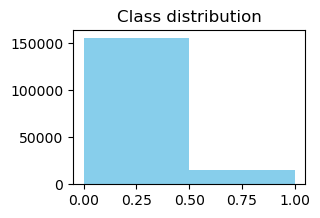

In [11]:
plt.figure(figsize=(3,2))
plt.hist(y_train_proc, bins=2, color="skyblue")
plt.title(f"Class distribution")
plt.show()

# Create New Features

In [13]:
# # CREATE NEW FEATURES

from sklearn.preprocessing import FunctionTransformer

def add_new_features(df):
    df_out = df.copy()
    df_out['amt_credit_to_price'] = df_out['AMT_CREDIT']/(df_out['AMT_GOODS_PRICE']+1)
    df_out['amt_credit_to_income'] = df_out['AMT_CREDIT']/ (df_out['AMT_INCOME_TOTAL']+1)
    df_out["overdue_ratio"] = df_out["AMT_CREDIT_SUM_OVERDUE"]/(df_out["AMT_CREDIT_SUM"] + 1)
    df_out["debt_to_credit"] = df_out["AMT_CREDIT_SUM_DEBT"] / (df_out["AMT_CREDIT_SUM"] + 1)
    df_out['credit_overdue_ratio'] = df_out['AMT_CREDIT_SUM_OVERDUE'] / (df_out['AMT_CREDIT_SUM']+1)
    df_out['credit_debt_ratio'] = df_out['AMT_CREDIT_SUM_DEBT'] / (df_out['AMT_CREDIT_SUM_LIMIT']+1)
    df_out['ext_sum'] = df_out['EXT_SOURCE_2'] + df_out['EXT_SOURCE_3']
    df_out["ext_mean"] = df_out[["EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)
    df_out["ext_prod"] = df_out["EXT_SOURCE_2"] * df_out["EXT_SOURCE_3"]
    df_out["ext_ratio"] = df_out["EXT_SOURCE_2"] / (df_out["EXT_SOURCE_3"] + 1)
    df_out["missing_ext2"] = df_out["EXT_SOURCE_2"].isna().astype(int)
    df_out["missing_ext3"] = df_out["EXT_SOURCE_3"].isna().astype(int)
    df_out['obs_social_circle'] = df_out['OBS_30_CNT_SOCIAL_CIRCLE'] + df_out['OBS_60_CNT_SOCIAL_CIRCLE']
    df_out['def_social_circle'] = df_out['DEF_30_CNT_SOCIAL_CIRCLE'] + df_out['DEF_60_CNT_SOCIAL_CIRCLE']
    df_out["obs_def_ratio"] = df_out["DEF_30_CNT_SOCIAL_CIRCLE"] / (df_out["OBS_30_CNT_SOCIAL_CIRCLE"] + 1)
    # df_out['balance_ratio'] = np.where(df_out['AMT_CREDIT_LIMIT_ACTUAL'] == 0, 0, df_out['AMT_BALANCE'] / df_out['AMT_CREDIT_LIMIT_ACTUAL'])
    # df_out['balance_remaining'] = np.where(df_out['AMT_PAYMENT_TOTAL_CURRENT'] == 0, 0, df_out['AMT_BALANCE'] - df_out['AMT_PAYMENT_TOTAL_CURRENT'])
    
    return df_out

# Aggregate Flags
def combine_doc_flags(df):
    df_out = df.copy()
    doc_flags = [col for col in df_out.columns if "FLAG_DOCUMENT" in col]
    df_out["docs_missing"] = df_out[doc_flags].sum(axis=1)
    return df_out

def region_mismatch(df):
    df_out = df.copy()
    region_cols = ["REG_REGION_NOT_LIVE_REGION", "REG_REGION_NOT_WORK_REGION", "LIVE_REGION_NOT_WORK_REGION", "REG_CITY_NOT_LIVE_CITY", "REG_CITY_NOT_WORK_CITY", "LIVE_CITY_NOT_WORK_CITY"]
    df_out["region_mismatch_count"] = df_out[region_cols].sum(axis=1)
    return df_out

add_new_features_step = FunctionTransformer(add_new_features)
combine_doc_flags_step = FunctionTransformer(combine_doc_flags)
region_mismatch_step = FunctionTransformer(region_mismatch)


# Pre Processing

In [ ]:
from sklearn.impute import SimpleImputer
X_train_final = df_5.copy()

categorical_pipeline = Pipeline([("ohe", OneHotEncoder(drop='first', handle_unknown="ignore", sparse_output=False))]) # used drop = 'first' to prevent perfect multicollinearity
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy="mean")), ('adding_features', add_new_features_step), ('combine_doc_flags', combine_doc_flags_step), ('region_mismatch', region_mismatch_step), ("scaler", StandardScaler())])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

preprocessor.set_output(transform="pandas")

X_train_proc = preprocessor.fit_transform(X_train_final)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(X_train_proc.columns.tolist())
print(X_train_proc.shape)
print(X_val_proc.shape)
print(X_test_proc.shape)
print(y_train_proc.shape)
print(y_val.shape)
print(y_test.shape)

y_val_proc = y_val
y_test_proc = y_test

## ALSO PREPARE BASELINE SET
# data before adding new features
categorical_pipeline = Pipeline([("ohe", OneHotEncoder(drop='first', handle_unknown="ignore", sparse_output=False))]) # used drop = 'first' to prevent perfect multicollinearity
numeric_pipeline_baseline = Pipeline([('imputer', SimpleImputer(strategy="mean")), ("scaler", StandardScaler())])

preprocessor_baseline = ColumnTransformer([
    ("num", numeric_pipeline_baseline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])
preprocessor_baseline.set_output(transform="pandas")

X_train_baseline = preprocessor_baseline.fit_transform(X_train_final)
X_val_baseline = preprocessor_baseline.transform(X_val)
X_test_baseline = preprocessor_baseline.transform(X_test)



# Baseline Results

In [ ]:
## Dummy Classifier
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train_baseline, y_train_proc)
dummy_probs = dummy.predict_proba(X_test_baseline)[:, 1]
dummy_preds = (dummy_probs >= 0.5).astype(int)

# Classification Report
report = classification_report(y_test, dummy_preds)

# Evaluation Metrics (one by one)
acc = accuracy_score(y_test, dummy_preds)
prec = precision_score(y_test, dummy_preds, zero_division=0)
rec = recall_score(y_test, dummy_preds, zero_division=0)
f1 = f1_score(y_test, dummy_preds, zero_division=0)
print(f'Baseline: Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1-score={f1:.4f}')
aucpr = average_precision_score(y_test, dummy_probs)
print(f'aucpr: {aucpr}')




## Logistic Regression
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_baseline, y_train_proc)
logreg_probs = logreg.predict_proba(X_test_baseline)[:, 1]
logred_preds = (dummy_probs >= 0.5).astype(int)

# Classification Report
report = classification_report(y_test, logred_preds)

# Evaluation Metrics (one by one)
acc = accuracy_score(y_test, logred_preds)
prec = precision_score(y_test, logred_preds, zero_division=0)
rec = recall_score(y_test, logred_preds, zero_division=0)
f1 = f1_score(y_test, logred_preds, zero_division=0)
print(f'Log Reg: Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1-score={f1:.4f}')
aucpr = average_precision_score(y_test, logreg_probs)
print(f'aucpr: {aucpr}')

# Gradient Boosted Tree (XGBoost)

## XGB - Visualize effects of varying hyperparameters

In [ ]:
# Calculate the ratio of negative (0) to positive (1) classes to balance the data
ratio = float(y_train_proc.value_counts()[0]) / y_train_proc.value_counts()[1] # ~11.3

def model_eval_xgb(learning_rate_, n_estimators_, max_depth_, subsample_, reg_alpha_, reg_lambda_, eval_metric_, verbose=100):
    xgb_model = xgb.XGBClassifier(
        n_estimators = n_estimators_,          
        learning_rate = learning_rate_,        # Step size
        max_depth = max_depth_,                # Maximum depth of a tree
        subsample = subsample_,
        scale_pos_weight=ratio,         # Balances the target classes for the imbalanced dataset
        eval_metric = eval_metric_, 
        random_state = RANDOM_STATE,
        reg_alpha = reg_alpha_,
        reg_lambda = reg_lambda_,
        early_stopping_rounds = 100      # Stop training if the validation score hasn't improved for 50 rounds
    )

    print("Training XGBoost model...")
    xgb_model.fit(
        X_train_proc, y_train_proc, 
        eval_set = [(X_train_proc, y_train_proc), (X_val_proc, y_val_proc)], # Evaluate on both train and val to monitor overfitting
        verbose = verbose  # Print the score every 50 trees
    )

    ## Extract the historical scores
    results = xgb_model.evals_result()
    train_eval = results['validation_0'][eval_metric_] # 'validation_0' matches X_train_proc
    val_eval = results['validation_1'][eval_metric_] # 'validation_1' matches X_val_proc
    best_iteration = xgb_model.best_iteration
    epochs = range(1, len(train_eval) + 1)

    return xgb_model, train_eval, val_eval, best_iteration, epochs


## STARTING HYPERPARAMETERS ##
def reset_xgb_parameters():
    global learning_rate_ # step size
    global n_estimators_ # number of gradient boosted trees
    global max_depth_ # tree depth
    global subsample_ # Subsample ratio of the training instance
    global reg_alpha_ # L1 regularization term
    global reg_lambda_ # L2 regularization term
    learning_rate_ = 0.05
    n_estimators_ = 1000
    max_depth_ = 5
    subsample_ = 0.8
    reg_alpha_ = 1
    reg_lambda_ = 1

Training XGBoost model...
Training XGBoost model...
Training XGBoost model...
Training XGBoost model...


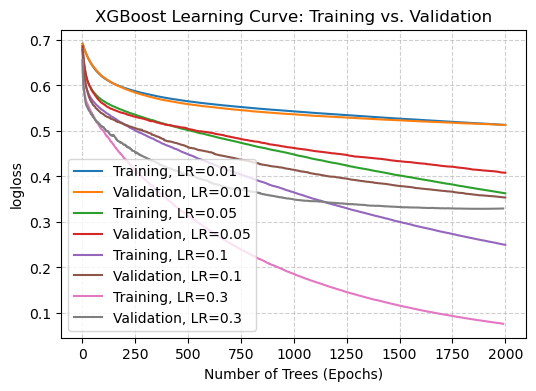

In [31]:
## learning_rate

reset_xgb_parameters()
eval_metric_ = 'logloss'

plt.figure(figsize=(6,4))

for learning_rate_ in [0.01, 0.05, 0.1, 0.3]:

    # Train and Evaluate
    _, train_eval, val_eval, best_iteration, epochs = model_eval_xgb(learning_rate_, n_estimators_, max_depth_, subsample_, reg_alpha_, reg_lambda_, eval_metric_, False)

    plt.plot(epochs, train_eval, label=f'Training, LR={learning_rate_}')
    plt.plot(epochs, val_eval, label=f'Validation, LR={learning_rate_}')
    
plt.title('XGBoost Learning Curve: Training vs. Validation')
plt.xlabel('Number of Trees (Epochs)')
plt.ylabel(eval_metric_)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
# Learning Rate
param_name = "learning_rate"
param_range = [0.01, 0.05, 0.1, 0.3]

train_scores, val_scores = validation_curve(
    xgb.XGBClassifier(random_state=RANDOM_STATE),
    X_train_proc, y_train_proc,
    param_name=param_name, param_range=param_range, scoring='neg_log_loss',
    cv=3, n_jobs=-1
)

# Convert to positive log loss
train_mean = -np.mean(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)

# Plot
plt.plot(param_range, train_mean, label="Train")
plt.plot(param_range, val_mean, label="Validation")
plt.xlabel(param_name)
plt.ylabel('log_loss')
plt.title("Validation Curve (XGB)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# n_estimators

praram_name='n_estimators'
param_range = [50, 100, 200, 400, 800]

train_scores, val_scores = validation_curve(
    xgb.XGBClassifier(random_state=RANDOM_STATE),
    X_train_proc, y_train_proc,
    param_name=praram_name, param_range=param_range, scoring='neg_log_loss',
    cv=3, n_jobs=-1
)

# Convert to positive log loss
train_mean = -np.mean(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)

# Plot
plt.plot(param_range, train_mean, label="Train")
plt.plot(param_range, val_mean, label="Validation")

plt.xlabel(praram_name)
plt.ylabel('log_loss')
plt.title("Validation Curve (XGB)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
## max_depth ##

reset_xgb_parameters()
eval_metric_ = 'logloss'

plt.figure(figsize=(6,4))

for max_depth_ in [3, 5, 7]:

    # Train and Evaluate
    _, train_eval, val_eval, best_iteration, epochs = model_eval_xgb(learning_rate_, n_estimators_, max_depth_, subsample_, reg_alpha_, reg_lambda_, eval_metric_, False)

    plt.plot(epochs, train_eval, label=f'Training, max_depth={max_depth_}')
    plt.plot(epochs, val_eval, label=f'Validation, max_depth={max_depth_}')
    
plt.title('XGBoost Learning Curve: Training vs. Validation')
plt.xlabel('Number of Trees (Epochs)')
plt.ylabel(eval_metric_)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# max_depth

param_name='max_depth'
param_range = [3,4,5,6]

train_scores, val_scores = validation_curve(
    xgb.XGBClassifier(random_state=RANDOM_STATE),
    X_train_proc, y_train_proc,
    param_name=param_name, param_range=param_range, scoring='neg_log_loss',
    cv=3, n_jobs=-1
)

# Convert to positive log loss
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot
plt.plot(param_range, train_mean, label="Train")
plt.plot(param_range, val_mean, label="Validation")

plt.xlabel("Max Depth")
plt.ylabel('log_loss')
plt.title("Validation Curve (XGB)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# subsample

train_scores, val_scores = validation_curve(
    xgb.XGBClassifier(random_state=RANDOM_STATE),
    X_train_proc, y_train_proc,
    param_name="subsample", param_range=[0.2, 0.4, 0.6, 0.8, 0.95], scoring='neg_log_loss',
    cv=3, n_jobs=-1
)

# Convert to positive log loss
train_mean = -np.mean(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)

# Plot
plt.plot(param_range, train_mean, label="Train")
plt.plot(param_range, val_mean, label="Validation")

plt.xlabel("Subsample Size")
plt.ylabel('log_loss')
plt.title("Validation Curve (XGB)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# reg_alpha  (L1)

train_scores, val_scores = validation_curve(
    xgb.XGBClassifier(random_state=RANDOM_STATE),
    X_train_proc, y_train_proc,
    param_name="reg_alpha", param_range=[2, 5, 10, 20, 30],
    scoring='neg_log_loss', cv=3, n_jobs=-1
)

# Convert to positive log loss
train_mean = -np.mean(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)

# Plot
plt.plot(param_range, train_mean, label="Train")
plt.plot(param_range, val_mean, label="Validation")

plt.xlabel("L1 Reg. Coefficient")
plt.ylabel('log_loss')
plt.title("Validation Curve (XGB)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# reg_lambda (L2)

train_scores, val_scores = validation_curve(
    xgb.XGBClassifier(random_state=RANDOM_STATE),
    X_train_proc,
    y_train_proc,
    param_name="reg_lambda", param_range=[2, 5, 10, 20, 30],
    scoring='neg_log_loss',
    cv=3, n_jobs=-1
)

# Convert to positive log loss
train_mean = -np.mean(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)

# Plot
plt.plot(param_range, train_mean, label="Train")
plt.plot(param_range, val_mean, label="Validation")

plt.xlabel("L2 Reg. Coefficient")
plt.ylabel('log_loss')
plt.title("Validation Curve (XGB)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## XGB - Grid Search for hyperparameter tuning ##

In [ ]:
'''
ratio = float(y_train_proc.value_counts()[0]) / y_train_proc.value_counts()[1] # ~11.3

# Base Model with Fixed Parameters
xgb_base = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state= RANDOM_STATE
)

# Grid of Parameters to Test
param_grid = {
    'reg_lambda': [1, 2, 5],      # L2
    'max_depth': [3, 5],
    'subsample': [0.8],    
    'reg_alpha': [1, 2, 5]        # L1
}

xgb_grid = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid, 
    scoring='neg_log_loss',
    # cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1    
)

print("Starting Grid Search...")
xgb_grid.fit(X_train_proc, y_train_proc, eval_set=[(X_val_proc, y_val)], verbose=False)

print(f"\nBest Parameters Found: {xgb_grid.best_params_}")
print(f"Best Cross-Validation Log Loss: -{xgb_grid.best_score_:.4f}")

# best_xgb_model = xgb_grid.best_estimator_ # fully trained XGBoost model using the winning parameters
'''


Starting Grid Search...

Best Parameters Found: {'max_depth': 5, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 0.8}
Best Cross-Validation AUC-PR: -0.5583


## XGB - Training ##

* USING LOG LOSS

Training XGBoost model...
[0]	validation_0-logloss:0.68588	validation_1-logloss:0.68592
[100]	validation_0-logloss:0.56421	validation_1-logloss:0.55772
[200]	validation_0-logloss:0.54132	validation_1-logloss:0.53611
[300]	validation_0-logloss:0.52511	validation_1-logloss:0.52174
[400]	validation_0-logloss:0.51092	validation_1-logloss:0.51223
[500]	validation_0-logloss:0.49822	validation_1-logloss:0.50299
[600]	validation_0-logloss:0.48636	validation_1-logloss:0.49574
[700]	validation_0-logloss:0.47510	validation_1-logloss:0.48735
[800]	validation_0-logloss:0.46394	validation_1-logloss:0.47817
[900]	validation_0-logloss:0.45334	validation_1-logloss:0.47019
[1000]	validation_0-logloss:0.44315	validation_1-logloss:0.46309
[1100]	validation_0-logloss:0.43301	validation_1-logloss:0.45427
[1200]	validation_0-logloss:0.42382	validation_1-logloss:0.45181
[1230]	validation_0-logloss:0.42100	validation_1-logloss:0.45005


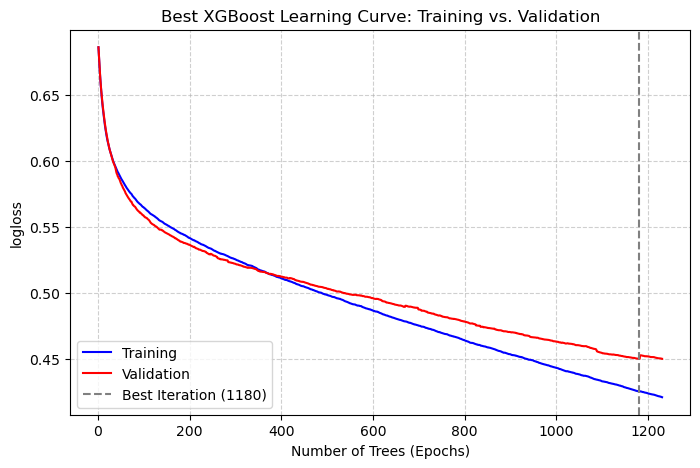

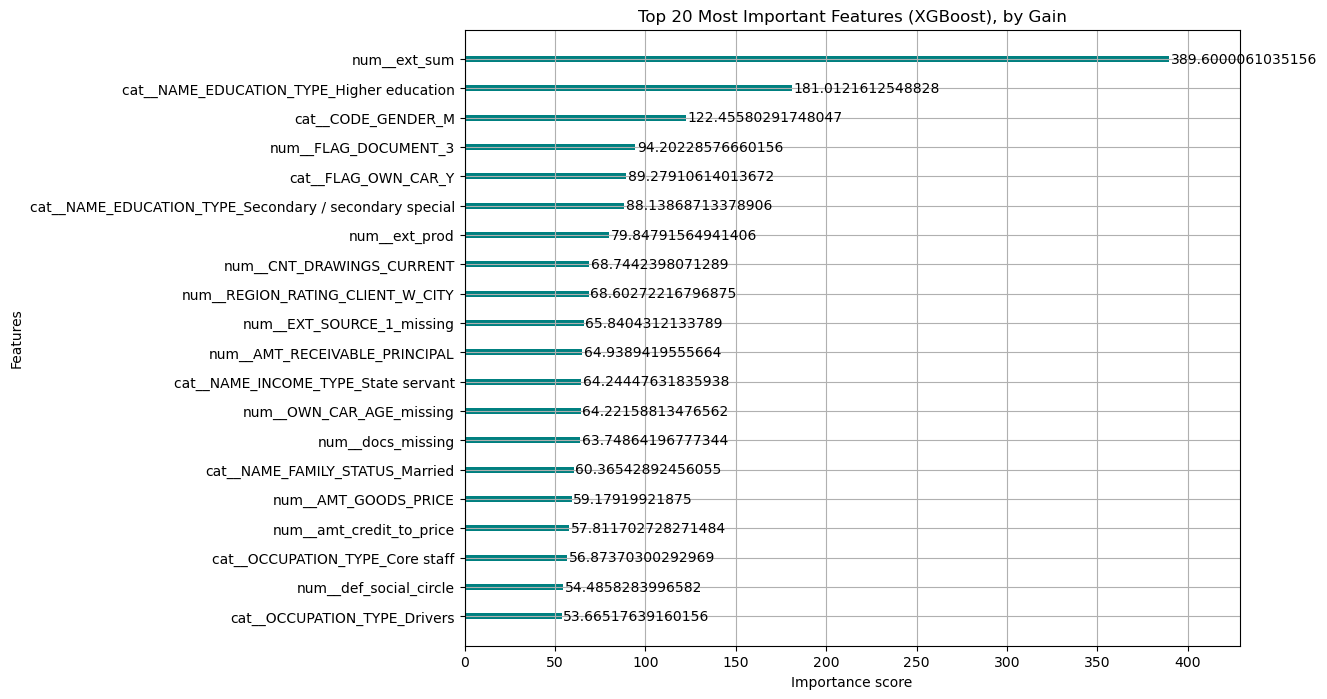

In [79]:
# Train Model and plot the convergence USING LOG LOSS

# Calculate the ratio of negative (0) to positive (1) classes to balance the data
ratio = float(y_train_proc.value_counts()[0]) / y_train_proc.value_counts()[1] # ~11.3

selected_xgb_model = xgb.XGBClassifier(
    n_estimators = 5000,          
    learning_rate = 0.05,        
    max_depth = 5,          
    subsample = 0.8,
    scale_pos_weight=ratio,
    eval_metric = 'logloss', 
    random_state = RANDOM_STATE,
    reg_alpha = 1,
    reg_lambda = 1,
    early_stopping_rounds = 50
)

print("Training XGBoost model...")
selected_xgb_model.fit(
    X_train_proc, y_train_proc, 
    eval_set = [(X_train_proc, y_train_proc), (X_val_proc, y_val_proc)],
    verbose = 100
)

## Extract the historical scores
results = selected_xgb_model.evals_result()
train_eval = results['validation_0']['logloss'] # 'validation_0' matches X_train_proc
val_eval = results['validation_1']['logloss'] # 'validation_1' matches X_val_proc
best_iteration = selected_xgb_model.best_iteration
epochs = range(1, len(train_eval) + 1)


## Plot the learning curve
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_eval, label='Training', color='blue')
plt.plot(epochs, val_eval, label='Validation', color='red')
plt.axvline(x=best_iteration, color='gray', linestyle='--', label=f'Best Iteration ({best_iteration})')
plt.title('Best XGBoost Learning Curve: Training vs. Validation')
plt.xlabel('Number of Trees (Epochs)')
plt.ylabel('logloss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## FEATURE IMPORTANCE ##
fig, ax = plt.subplots(figsize=(10, 8))

plot_importance(
    selected_xgb_model, 
    ax=ax, 
    max_num_features=20, 
    importance_type='gain',  # 'gain' measures the actual improvement in accuracy brought by a feature to the branches it is on
    title='Top 20 Most Important Features (XGBoost), by Gain',
    color='teal'
)

plt.show()

## XGB - Evaluation


=== Train Performance ===
XGBoost: Accuracy=0.9494 | Precision=0.6344 | Recall=0.9977 | F1-score=0.7756
aucpr: 0.6331198790585123

=== Validation Performance ===
XGBoost: Accuracy=0.8657 | Precision=0.2485 | Recall=0.3275 | F1-score=0.2826
aucpr: 0.1356609022533133


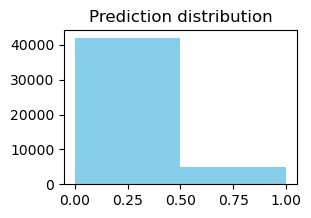

In [ ]:
def evaluate_model(y_test, y_pred, threshold, name, graph_cm ="yes"):

    y_pred = (y_pred > threshold).astype(int) # doesn't matter for Gaussian NB

    # Classification Report
    report = classification_report(y_test, y_pred)

    # Confusion Matrix Plot
    if graph_cm == "yes":
        print('')
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6,4))
        ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        ax.invert_xaxis()
        ax.invert_yaxis()
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"{name} Confusion Matrix")
        # plt.savefig(f"{name}_confusion_matrix.png", dpi=300, bbox_inches="tight")
        plt.show()

    # Evaluation Metrics (one by one)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f'{name}: Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1-score={f1:.4f}')
    
    return acc, prec, rec, f1



## EVALUATE XGBOOST ## 
threshold = 0.5
graph_cm = "no"

# Train
print('\n=== Train Performance ===')
y_train_pred_xgb = selected_xgb_model.predict(X_train_proc)
evaluate_model(y_train_proc, y_train_pred_xgb, threshold, 'XGBoost', graph_cm)

aucpr = average_precision_score(y_train_proc, y_train_pred_xgb)

# print(f'acc: {acc} | prec: {prec} | rec: {rec} | f1: {f1}')
print(f'aucpr: {aucpr}')

# Validation
print('\n=== Validation Performance ===')
y_val_pred_xgb = selected_xgb_model.predict(X_val_proc)
evaluate_model(y_val, y_val_pred_xgb, threshold, 'XGBoost', graph_cm)

aucpr = average_precision_score(y_val, y_val_pred_xgb)

# print(f'acc: {acc} | prec: {prec} | rec: {rec} | f1: {f1}')
print(f'aucpr: {aucpr}')

# Plot Prediction Distribution
plt.figure(figsize=(3,2))
plt.hist(y_val_pred_xgb, bins=2, color="skyblue")
plt.title(f"Prediction distribution")
plt.show()


In [70]:
graph_cm = "no"

## EVALUATE on TEST SET ## 
print('=== XGB Test Performance ===')
# y_preds_xgb = selected_xgb_model.predict(X_test_proc)
y_preds_xgb = selected_xgb_model.predict_proba(X_test_proc)[:, 1]
evaluate_model(y_test, y_preds_xgb, 0.5, 'XGBoost', graph_cm)
aucpr = average_precision_score(y_test, y_preds_xgb)
print(f'aucpr: {aucpr}')


=== XGB Test Performance ===
XGBoost: Accuracy=0.8687 | Precision=0.2580 | Recall=0.3340 | F1-score=0.2912
aucpr: 0.23567663096864253


# MLP

## MLP - Visualize effects of varying hyperparameters


In [71]:
# sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_proc)

def model_eval_mlp(hidden_layer_sizes_, activation_, learning_rate_init_, max_iter_, alpha_):
    mlp_model = MLPClassifier(
        solver='adam',           
        early_stopping=True,
        random_state=RANDOM_STATE,
        hidden_layer_sizes = hidden_layer_sizes_,
        activation = activation_,
        learning_rate_init = learning_rate_init_,
        max_iter = max_iter_,
        n_iter_no_change=30,
        alpha=alpha_
    )

    print("Training MLP...")
    mlp_model.fit(X_train_proc, y_train_proc)

    ## Extract the historical scores
    loss_curve = mlp_model.loss_curve_
    epochs = range(1, len(loss_curve) + 1)

    return mlp_model, loss_curve, epochs

## STARTING HYPERPARAMETERS ##
def reset_mlp_parameters():
    global hidden_layer_sizes_
    global activation_
    global learning_rate_init_
    global max_iter_
    hidden_layer_sizes_ = (128,64)
    activation_ = 'relu'
    learning_rate_init_ = 0.01
    max_iter_ = 2000

Training MLP...
Training MLP...
Training MLP...


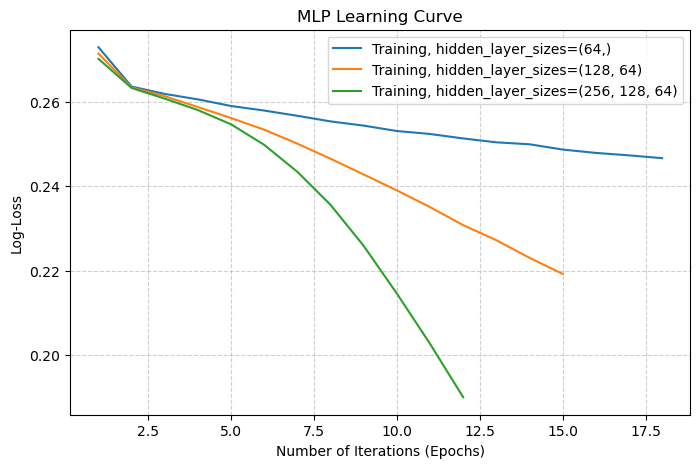

In [ ]:
# hidden_layer_sizes_

reset_mlp_parameters()

plt.figure(figsize=(6, 4))

for hidden_layer_sizes_ in [(64,), (128, 64), (256,128,64)]:

    _, loss_curve, epochs = model_eval_mlp(hidden_layer_sizes_, activation_, learning_rate_init_, max_iter_)

    plt.plot(epochs, loss_curve, label=f'Training, hidden_layer_sizes={hidden_layer_sizes_}')
    
plt.title('MLP Learning Curve')
plt.xlabel('Number of Iterations (Epochs)')
plt.ylabel('Log-Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

(32,) → Train Log Loss: 0.2590, Val Log Loss: 5.9670
(64,) → Train Log Loss: 0.2550, Val Log Loss: 6.3188
(128, 64) → Train Log Loss: 0.2550, Val Log Loss: 2.5029
(256, 128, 64) → Train Log Loss: 0.2627, Val Log Loss: 0.2911


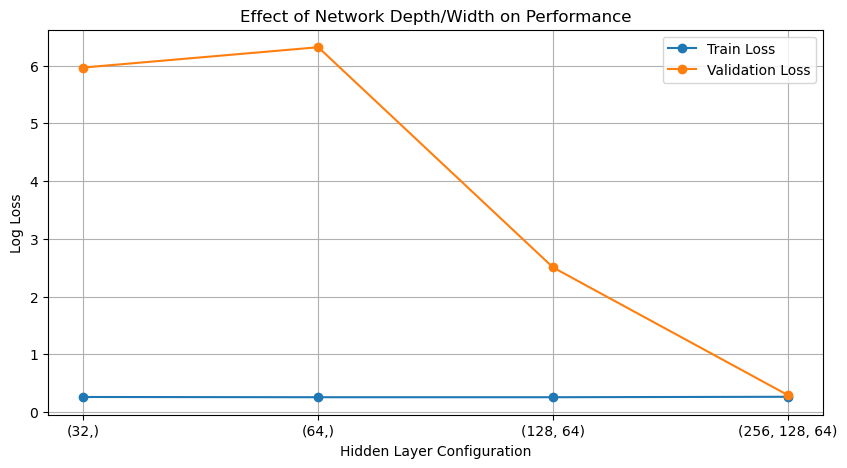

In [ ]:
# Hidden Layers

hidden_layer_options = [
    (32,),           # 1 layer, 32 neurons
    (64,),           # 1 layer, 64 neurons
    (128, 64),       # 2 layers
    (256, 128, 64),  # 3 layers
]
train_losses = []
val_losses = []
layer_configs = []

for layers in hidden_layer_options:
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        solver='adam',
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        random_state=RANDOM_STATE
    )
    
    mlp.fit(X_train_proc, y_train_proc)
    
    # Training loss
    y_train_pred = mlp.predict_proba(X_train_proc)[:, 1]
    train_loss = log_loss(y_train_proc, y_train_pred)
    
    # Validation loss
    y_val_pred = mlp.predict_proba(X_val_proc)[:, 1]
    val_loss = log_loss(y_val, y_val_pred)
    
    layer_configs.append(str(layers))
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"{layers} → Train Log Loss: {train_loss:.4f}, Val Log Loss: {val_loss:.4f}")

x = range(len(layer_configs))
plt.figure(figsize=(6,4))
plt.plot(x, train_losses, marker='o', label='Train Loss')
plt.plot(x, val_losses, marker='o', label='Validation Loss')
plt.xticks(x, layer_configs)
plt.xlabel("Hidden Layer Configuration")
plt.ylabel("Log Loss")
plt.title("Effect of Network Depth/Width on Performance")
plt.legend()
plt.grid(True)
plt.show()

Training MLP...
Training MLP...


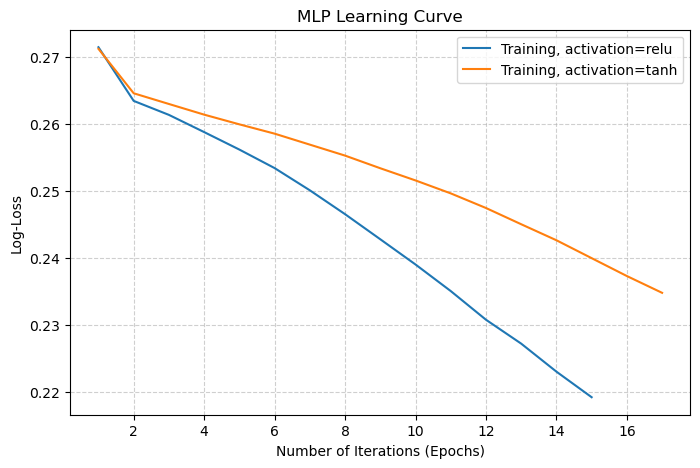

In [ ]:
# activation_

reset_mlp_parameters()

plt.figure(figsize=(6,4))

for activation_ in ['relu', 'tanh']:

    _, loss_curve, epochs = model_eval_mlp(hidden_layer_sizes_, activation_, learning_rate_init_, max_iter_)

    plt.plot(epochs, loss_curve, label=f'Training, activation={activation_}')
    
plt.title('MLP Learning Curve')
plt.xlabel('Number of Iterations (Epochs)')
plt.ylabel('Log-Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


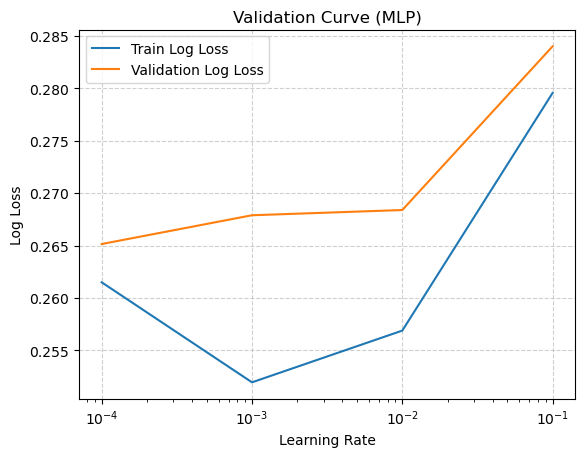

In [ ]:
# Learning Rate

param_range = 

train_scores, val_scores = validation_curve(
    MLPClassifier(
        solver='adam',
        early_stopping=True,
        random_state=RANDOM_STATE
    ),
    X_train_proc, y_train_proc,
    param_name="learning_rate_init", param_range=[0.0001, 0.001, 0.01, 0.1],
    scoring="neg_log_loss",
    cv=3,              # uses CV internally
    n_jobs=-1
)

# Convert to positive log loss
train_mean = -np.mean(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)

# Plot
plt.plot(param_range, train_mean, label="Train Log Loss")
plt.plot(param_range, val_mean, label="Validation Log Loss")

plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Log Loss")
plt.title("Validation Curve (MLP)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## MLP - Grid Search for Hyperparameter Tuning

In [ ]:
# sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_proc)

# Base MLP Model
mlp_base = MLPClassifier(
    solver='adam',         
    early_stopping=True,   
    random_state=RANDOM_STATE,
    n_iter_no_change = 30,
    verbose = False,
    # max_iter = max_iter_,
    max_iter = 150,
    # learning_rate_init = 0.01
)

# Parameter grid
param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32),(128, 64, 32)],
    'activation': ['relu'],
    'alpha': [0.1],
    'learning_rate_init':[0.01, 0.005]  
}

# Grid Search
mlp_grid = GridSearchCV(
    estimator=mlp_base, 
    param_grid=param_grid, 
    scoring='neg_log_loss', 
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    verbose=3,              
    n_jobs=-1            
)

print("Starting MLP Hyperparameter Search...")
mlp_grid.fit(X_train_proc, y_train_proc)

print(f"\nBest Settings Found: {mlp_grid.best_params_}")
print(f"Best {scoring_name} Score: {mlp_grid.best_score_:.4f}")

# best_mlp_model = mlp_grid.best_estimator_ # trained model with best hyperparameters



Starting MLP Hyperparameter Search...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


## MLP - Training ##

In [ ]:
# Train Model and plot convergence

selected_mlp_model = MLPClassifier(
    solver='adam',           
    early_stopping=True,
    random_state=RANDOM_STATE,
    hidden_layer_sizes = (64, 32),
    activation = 'relu',
    learning_rate_init = 0.0005,
    max_iter = 1000,
    n_iter_no_change=30,
    alpha=0.02
)

print("Training MLP...")
selected_mlp_model.fit(X_train_proc, y_train_proc)

## Extract the historical scores
loss_curve = selected_mlp_model.loss_curve_
epochs = range(1, len(loss_curve) + 1)

# Plot Train Log Loss
plt.plot(loss_curve)
plt.title("MLP Training Loss Convergence")
plt.xlabel("Epochs")
plt.ylabel("Log-Loss")
plt.show()


In [ ]:
## Evaluate Performance
graph_cm = "yes"

# Train
print('=== Train Set Performance ===')
y_train_pred_mlp = selected_mlp_model.predict_proba(X_train_proc)[:, 1]
evaluate_model(y_train_proc, y_train_pred_mlp, 0.5, 'MLP', 'yes')
aucpr = average_precision_score(y_train_proc, y_train_pred_mlp)
print(f'aucpr: {aucpr}')

# Validation
print('=== Validation Performance ===')
y_val_pred_mlp = selected_mlp_model.predict_proba(X_val_proc)[:, 1]
evaluate_model(y_val, y_val_pred_mlp, 0.5, 'MLP', 'yes')
aucpr = average_precision_score(y_val, y_val_pred_mlp)
print(f'aucpr: {aucpr}')

# Plot Prediction Distribution
plt.figure(figsize=(3,2))
plt.hist(y_val_pred_mlp, bins=2, color="skyblue")
plt.title(f"Prediction distribution")
plt.show()


In [ ]:
print('=== MLP Test Performance ===')
# y_preds_mlp = selected_mlp_model.predict(X_test_proc)
y_preds_mlp = selected_mlp_model.predict_proba(X_test_proc)[:, 1]
evaluate_model(y_test, y_preds_mlp, 0.5, 'MLP', graph_cm)
aucpr = average_precision_score(y_test, y_preds_mlp)
print(f'aucpr: {aucpr}')